## Setup
Standard imports and display/plot defaults for the notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

## Load data
Load the merged Task 1 output and derive a `YEARMONTH` key (e.g. `201807` for July 2018) so transactions can be grouped by calendar month per store.

In [2]:
data = pd.read_csv(r'D:\New folder\QVI_merged_data.csv')
data['DATE'] = pd.to_datetime(data['DATE'])
data['YEARMONTH'] = data['DATE'].dt.year * 100 + data['DATE'].dt.month

print(data.shape)
print(data['STORE_NBR'].nunique(), "stores")
data.head()

(255510, 13)
272 stores


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER,YEARMONTH
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175.0,NATURAL CHIP CO,YOUNG SINGLES/COUPLES,Premium,201810
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175.0,CCS,MIDAGE SINGLES/COUPLES,Budget,201905
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170.0,SMITHS,MIDAGE SINGLES/COUPLES,Budget,201905
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175.0,SMITHS,MIDAGE SINGLES/COUPLES,Budget,201808
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150.0,KETTLE,MIDAGE SINGLES/COUPLES,Budget,201808


## Build monthly store metrics
Collapse transaction-level rows into one row per store per month: total sales, unique customers, unique transactions, and total units sold. From these, derive the metrics the task asks for (`TXN_PER_CUSTOMER`) plus two extra diagnostic ratios (`CHIPS_PER_TXN`, `AVG_PRICE_PER_UNIT`) that can help explain *why* a change happened, not just *that* it happened.

In [3]:
monthly_data = data.groupby(['STORE_NBR', 'YEARMONTH']).agg(
    TOT_SALES=('TOT_SALES', 'sum'),
    N_CUSTOMERS=('LYLTY_CARD_NBR', 'nunique'),
    N_TXN=('TXN_ID', 'nunique'),
    N_CHIPS=('PROD_QTY', 'sum')
).reset_index()

monthly_data['TXN_PER_CUSTOMER'] = monthly_data['N_TXN'] / monthly_data['N_CUSTOMERS']
monthly_data['CHIPS_PER_TXN'] = monthly_data['N_CHIPS'] / monthly_data['N_TXN']
monthly_data['AVG_PRICE_PER_UNIT'] = monthly_data['TOT_SALES'] / monthly_data['N_CHIPS']

print(monthly_data.shape)
monthly_data.head(10)

(3169, 9)


,STORE_NBR,YEARMONTH,TOT_SALES,N_CUSTOMERS,N_TXN,N_CHIPS,TXN_PER_CUSTOMER,CHIPS_PER_TXN,AVG_PRICE_PER_UNIT
0,1,201807,191.6,48,50,59,1.041667,1.180000,3.247458
1,1,201808,171.0,42,42,53,1.000000,1.261905,3.226415
2,1,201809,273.7,58,61,74,1.051724,1.213115,3.698649
3,1,201810,188.1,44,45,58,1.022727,1.288889,3.243103
4,1,201811,187.5,45,46,56,1.022222,1.217391,3.348214
5,1,201812,169.2,40,44,53,1.100000,1.204545,3.192453
6,1,201901,149.7,35,35,41,1.000000,1.171429,3.651220
7,1,201902,199.9,50,52,60,1.040000,1.153846,3.331667
8,1,201903,187.8,44,48,57,1.090909,1.187500,3.294737
9,1,201904,187.8,41,42,56,1.024390,1.333333,3.353571


## Define pre-trial and trial periods
The trial ran **February to April 2019**. Everything before that (July 2018 to January 2019, 7 months) is the pre-trial baseline — the only window we're allowed to use when judging how similar a candidate control store is to a trial store, since using trial-period data to pick a control would be circular.

In [4]:
pretrial_months = [201807, 201808, 201809, 201810, 201811, 201812, 201901]
trial_months = [201902, 201903, 201904]

print("Pre-trial months:", pretrial_months, "-> count:", len(pretrial_months))
print("Trial months:", trial_months)

Pre-trial months: [201807, 201808, 201809, 201810, 201811, 201812, 201901] -> count: 7
Trial months: [201902, 201903, 201904]


## Sanity-check: does each proposed control track its trial store pre-trial?
Before trusting a control store, plot its monthly value against the trial store's, restricted to the pre-trial window, with all other stores shown for context. A good control should visually track the trial store's line before February 2019.

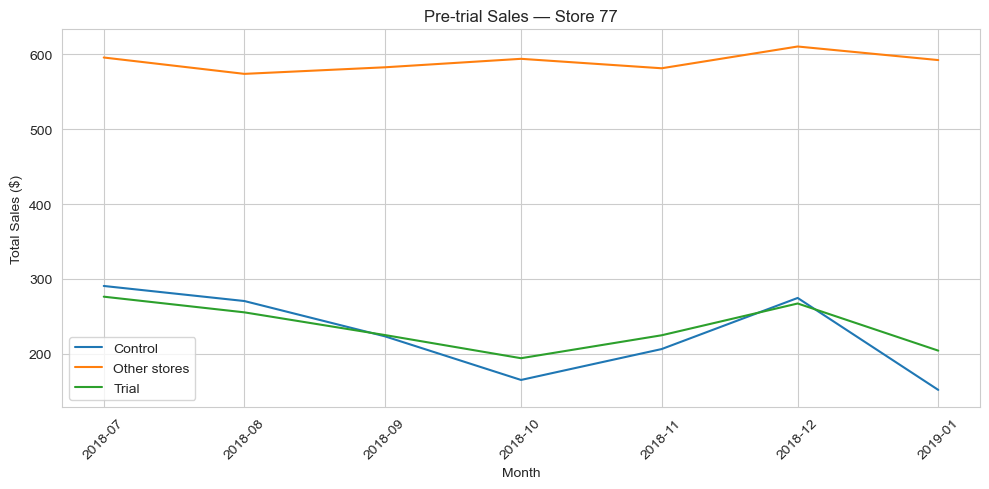

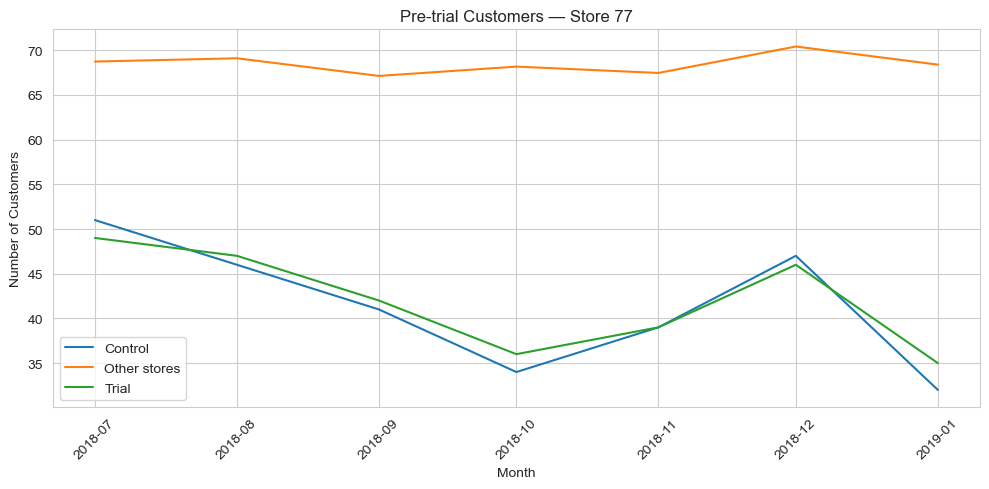

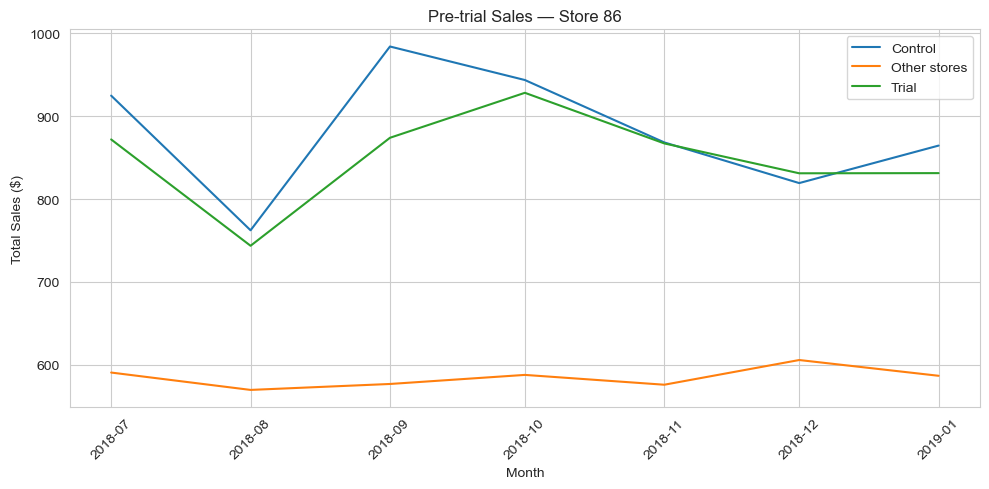

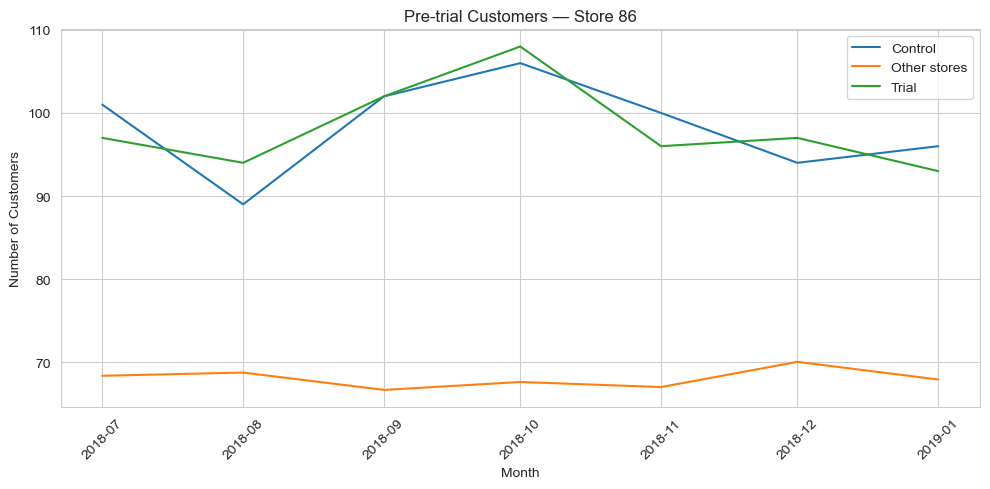

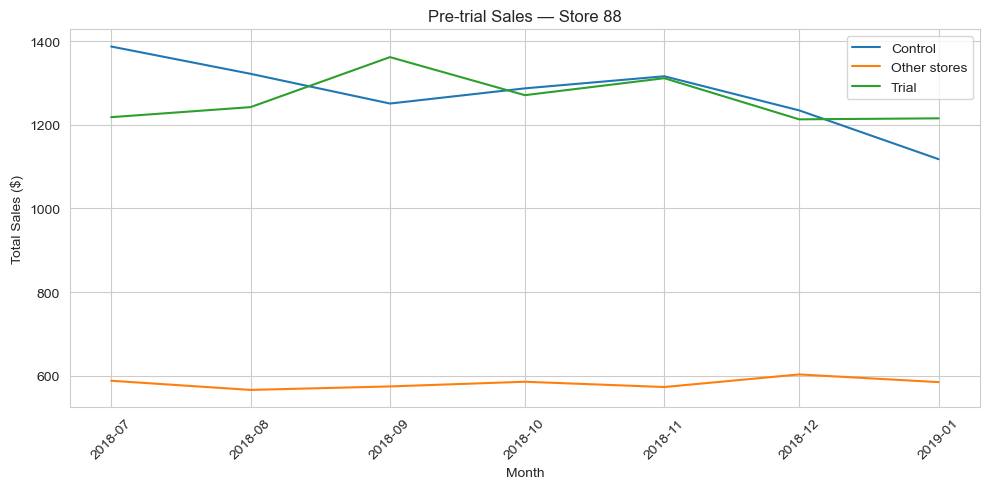

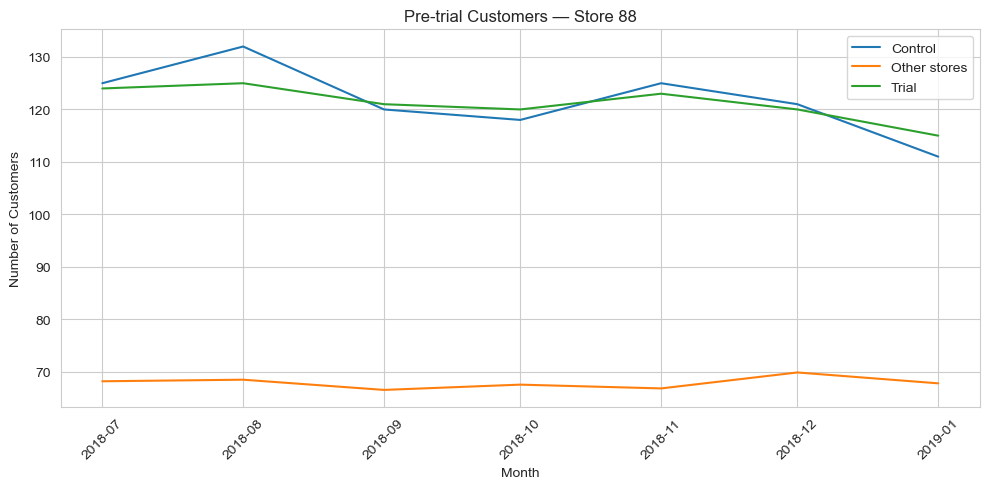

In [5]:
def plot_pretrial_check(metric_col, trial_store, control_store, ylabel, title_metric):
    check_data = monthly_data[monthly_data['YEARMONTH'] < 201902].copy()
    check_data['Store_type'] = check_data['STORE_NBR'].apply(
        lambda x: 'Trial' if x == trial_store else ('Control' if x == control_store else 'Other stores')
    )
    grouped = check_data.groupby(['YEARMONTH', 'Store_type'])[metric_col].mean().reset_index()
    grouped['TransactionMonth'] = pd.to_datetime(grouped['YEARMONTH'].astype(str), format='%Y%m')

    plt.figure(figsize=(10, 5))
    for store_type, grp in grouped.groupby('Store_type'):
        plt.plot(grp['TransactionMonth'], grp[metric_col], label=store_type)
    plt.xlabel('Month')
    plt.ylabel(ylabel)
    plt.title(f'Pre-trial {title_metric} — Store {trial_store}')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Store 77
plot_pretrial_check('TOT_SALES', 77, 233, 'Total Sales ($)', 'Sales')
plot_pretrial_check('N_CUSTOMERS', 77, 233, 'Number of Customers', 'Customers')

# Store 86
plot_pretrial_check('TOT_SALES', 86, 155, 'Total Sales ($)', 'Sales')
plot_pretrial_check('N_CUSTOMERS', 86, 155, 'Number of Customers', 'Customers')

# Store 88
plot_pretrial_check('TOT_SALES', 88, 237, 'Total Sales ($)', 'Sales')
plot_pretrial_check('N_CUSTOMERS', 88, 237, 'Number of Customers', 'Customers')

## Filter to stores with full 12-month observation
First pass: restrict candidates to stores with a full 12 months of history, then build `pretrial_data` using the explicit `pretrial_months` list.

**Note:** this `pretrial_data` gets rebuilt again two cells below using `YEARMONTH < 201902` instead of `isin(pretrial_months)`. Both should produce the same 7 months, but having two different code paths build the same variable name is worth tidying up — keep one as the single source of truth for `pretrial_data` and drop the other.

In [6]:
full_coverage_stores = monthly_data.groupby('STORE_NBR')['YEARMONTH'].count()
full_coverage_stores = full_coverage_stores[full_coverage_stores == 12].index

pretrial_data = monthly_data[
    (monthly_data['YEARMONTH'].isin(pretrial_months)) &
    (monthly_data['STORE_NBR'].isin(full_coverage_stores))
]

print(pretrial_data.shape)
print(pretrial_data['STORE_NBR'].nunique(), "stores eligible as controls")


(1820, 9)
260 stores eligible as controls


### Filter to stores with full 12-month observation
Before comparing potential control stores to the trial stores, we restrict the comparison pool to stores that have data for all 12 months of the observation period. Stores with incomplete data (e.g. newly opened or closed stores) would give unreliable similarity scores, since there'd be no full pre-trial history to compare against.

We then isolate the **pre-trial period** (before February 2019) — this is the baseline period used to find the best-matching control store for each trial store, before the trial's effects come into play.

Second pass at the same filter, this time using `YEARMONTH < 201902`. This is the version of `pretrial_data` that actually gets used by the correlation/magnitude functions further down, since it's the one built last.

In [7]:
store_month_counts = monthly_data.groupby('STORE_NBR')['YEARMONTH'].nunique()
stores_with_full_obs = store_month_counts[store_month_counts == 12].index.tolist()

print("Stores with full 12-month observation:", len(stores_with_full_obs))

pretrial_data = monthly_data[
    (monthly_data['YEARMONTH'] < 201902) &
    (monthly_data['STORE_NBR'].isin(stores_with_full_obs))
].copy()

print("Pre-trial shape:", pretrial_data.shape)

Stores with full 12-month observation: 260
Pre-trial shape: (1820, 9)


## Select control stores

Now that we have clean pre-trial data, we need a way to measure how similar each potential control store is to a given trial store. We'll use two complementary measures:

1. **Correlation** — measures whether a store's monthly *trend* (ups and downs) moves in the same pattern as the trial store, regardless of the actual size of the numbers.
2. **Magnitude distance** — measures how close a store's actual *values* are to the trial store's values (added next).

We write these as reusable functions so we don't have to repeat the analysis manually for each of the three trial stores (77, 86, 88).

### Correlation function
For a chosen metric (e.g. total sales), this function calculates the Pearson correlation between the trial store's monthly values and every other store's monthly values. A correlation close to **1** means the store's trend closely tracks the trial store's trend.

### Correlation function
For a chosen metric (e.g. total sales), calculate the Pearson correlation between the trial store's monthly values and every other store's monthly values. A correlation close to 1 means a candidate store's month-to-month pattern closely tracks the trial store's.

In [8]:
def calculate_correlation(input_table, metric_col, store_comparison):
    """
    For a given trial store, calculate the correlation between its monthly
    pattern and every other store's monthly pattern, for a chosen metric.
    """
    correlations = []
    trial_series = input_table[input_table['STORE_NBR'] == store_comparison].sort_values('YEARMONTH')[metric_col].reset_index(drop=True)
    
    store_numbers = input_table['STORE_NBR'].unique()
    
    for store in store_numbers:
        other_series = input_table[input_table['STORE_NBR'] == store].sort_values('YEARMONTH')[metric_col].reset_index(drop=True)
        
        if len(other_series) == len(trial_series):
            corr = trial_series.corr(other_series)
        else:
            corr = np.nan
        
        correlations.append({'Store1': store_comparison, 'Store2': store, 'corr_measure': corr})
    
    return pd.DataFrame(correlations)

Test the correlation function on trial store 77 for total sales and customer counts, and preview the top 10 highest-correlated candidate stores.

In [9]:
corr_sales_77 = calculate_correlation(pretrial_data, 'TOT_SALES', 77)
corr_customers_77 = calculate_correlation(pretrial_data, 'N_CUSTOMERS', 77)

print(corr_sales_77.sort_values('corr_measure', ascending=False).head(10))

     Store1  Store2  corr_measure
72       77      77      1.000000
221      77     233      0.974107
38       77      41      0.900107
46       77      50      0.890306
111      77     119      0.840297
67       77      71      0.826861
154      77     162      0.823976
15       77      17      0.749214
108      77     115      0.740194
28       77      30      0.704060


### Magnitude distance function
Correlation alone only tells us whether a store's sales *trend* moves in the same pattern as the trial store — it doesn't tell us whether the actual sales *volume* is similar. A tiny store and a large store could still be highly correlated if they both rise and fall together, even though they're not realistically comparable in size.

This function addresses that gap by measuring how close each store's actual monthly values are to the trial store's values. For each month, it calculates the absolute difference between the trial store and every other store, then rescales this into a **0 to 1 score** using the formula:

`1 - (observed distance - minimum distance) / (maximum distance - minimum distance)`

A score of **1** means the store's values were the closest match to the trial store that month; a score of **0** means it was the furthest. This is averaged across all pre-trial months to get one final magnitude score per store.

Together, correlation (trend shape) and magnitude distance (actual scale) give a fuller picture of how similar a potential control store really is to the trial store.

### Magnitude distance function
Correlation alone only tells us whether a store's trend moves in the same *shape* as the trial store — not whether the actual *size* of its sales is comparable. This function scores each candidate on how close its monthly values are to the trial store's, using `1 - (observed distance - minimum distance) / (maximum distance - minimum distance)` so the closest-matching store each month scores near 1.

In [10]:
def calculate_magnitude_distance(input_table, metric_col, store_comparison):
    """
    For a given trial store, calculate a standardised magnitude distance
    (0 to 1, where 1 = most similar) between its monthly values and every
    other store's monthly values, for a chosen metric.
    """
    trial_data = input_table[input_table['STORE_NBR'] == store_comparison][['YEARMONTH', metric_col]]
    trial_data = trial_data.rename(columns={metric_col: 'trial_value'})
    
    store_numbers = input_table['STORE_NBR'].unique()
    
    dist_rows = []
    for store in store_numbers:
        other_data = input_table[input_table['STORE_NBR'] == store][['YEARMONTH', metric_col]]
        other_data = other_data.rename(columns={metric_col: 'other_value'})
        
        merged = pd.merge(trial_data, other_data, on='YEARMONTH')
        merged['Store2'] = store
        merged['measure'] = abs(merged['trial_value'] - merged['other_value'])
        dist_rows.append(merged[['YEARMONTH', 'Store2', 'measure']])
    
    dist_table = pd.concat(dist_rows, ignore_index=True)
    
    # Standardise: for each month, scale distance to a 0-1 range
    min_max = dist_table.groupby('YEARMONTH')['measure'].agg(minDist='min', maxDist='max').reset_index()
    dist_table = pd.merge(dist_table, min_max, on='YEARMONTH')
    dist_table['magnitude_measure'] = 1 - (dist_table['measure'] - dist_table['minDist']) / (dist_table['maxDist'] - dist_table['minDist'])
    
    final_dist = dist_table.groupby('Store2')['magnitude_measure'].mean().reset_index()
    final_dist['Store1'] = store_comparison
    final_dist = final_dist.rename(columns={'magnitude_measure': 'mag_measure'})
    
    return final_dist[['Store1', 'Store2', 'mag_measure']]

Test the magnitude distance function on trial store 77 for total sales, previewing the top 10 closest-scoring candidates.

In [11]:
mag_sales_77 = calculate_magnitude_distance(pretrial_data, 'TOT_SALES', 77)
mag_customers_77 = calculate_magnitude_distance(pretrial_data, 'N_CUSTOMERS', 77)

print(mag_sales_77.sort_values('mag_measure', ascending=False).head(10))

     Store1  Store2  mag_measure
72       77      77     1.000000
221      77     233     0.983783
180      77     188     0.979286
196      77     205     0.974987
46       77      50     0.974400
123      77     131     0.974175
242      77     255     0.973162
203      77     214     0.972259
42       77      46     0.972069
49       77      53     0.972053


### Combine correlation and magnitude, and select the control store
Weight correlation and magnitude 50/50 per metric (sales, customers), then average the two metric-level scores into one `final_score` per candidate. The trial store is excluded from its own candidate list — otherwise it would always rank #1 by matching itself perfectly — and the top-ranked remaining store becomes the control.

In [12]:
def combine_scores(corr_table, mag_table, weight=0.5):
    combined = pd.merge(corr_table, mag_table, on=['Store1', 'Store2'])
    combined['score'] = weight * combined['corr_measure'] + (1 - weight) * combined['mag_measure']
    return combined

score_sales_77 = combine_scores(corr_sales_77, mag_sales_77)
score_customers_77 = combine_scores(corr_customers_77, mag_customers_77)

# Combine sales score and customer score into one final score
final_score_77 = pd.merge(
    score_sales_77[['Store1', 'Store2', 'score']].rename(columns={'score': 'score_sales'}),
    score_customers_77[['Store1', 'Store2', 'score']].rename(columns={'score': 'score_customers'}),
    on=['Store1', 'Store2']
)
final_score_77['final_score'] = 0.5 * final_score_77['score_sales'] + 0.5 * final_score_77['score_customers']

# Exclude store 77 itself, then find the best match
control_store_77 = final_score_77[final_score_77['Store2'] != 77].sort_values('final_score', ascending=False)
print(control_store_77.head(10))

     Store1  Store2  score_sales  score_customers  final_score
221      77     233     0.978945         0.986997     0.982971
38       77      41     0.929535         0.913481     0.921508
46       77      50     0.932353         0.829671     0.881012
241      77     254     0.806351         0.952261     0.879306
108      77     115     0.836104         0.823118     0.829611
15       77      17     0.820432         0.817527     0.818980
32       77      35     0.786217         0.842888     0.814552
25       77      27     0.744208         0.877716     0.810962
79       77      84     0.727505         0.880026     0.803765
159      77     167     0.780132         0.813711     0.796921


Repeat the full control-selection pipeline for trial store 86, reusing the same functions so no logic is rewritten — only the trial store number changes.

In [13]:
# Trial store 86
corr_sales_86 = calculate_correlation(pretrial_data, 'TOT_SALES', 86)
corr_customers_86 = calculate_correlation(pretrial_data, 'N_CUSTOMERS', 86)
mag_sales_86 = calculate_magnitude_distance(pretrial_data, 'TOT_SALES', 86)
mag_customers_86 = calculate_magnitude_distance(pretrial_data, 'N_CUSTOMERS', 86)

score_sales_86 = combine_scores(corr_sales_86, mag_sales_86)
score_customers_86 = combine_scores(corr_customers_86, mag_customers_86)

final_score_86 = pd.merge(
    score_sales_86[['Store1', 'Store2', 'score']].rename(columns={'score': 'score_sales'}),
    score_customers_86[['Store1', 'Store2', 'score']].rename(columns={'score': 'score_customers'}),
    on=['Store1', 'Store2']
)
final_score_86['final_score'] = 0.5 * final_score_86['score_sales'] + 0.5 * final_score_86['score_customers']

control_store_86 = final_score_86[final_score_86['Store2'] != 86].sort_values('final_score', ascending=False)
print(control_store_86.head(5))

     Store1  Store2  score_sales  score_customers  final_score
147      86     155     0.906024         0.874956     0.890490
107      86     114     0.852979         0.907224     0.880102
130      86     138     0.899918         0.828637     0.864277
219      86     231     0.743511         0.815426     0.779469
139      86     147     0.805728         0.735499     0.770614


Repeat the full control-selection pipeline for trial store 88.

In [14]:
# Trial store 88
corr_sales_88 = calculate_correlation(pretrial_data, 'TOT_SALES', 88)
corr_customers_88 = calculate_correlation(pretrial_data, 'N_CUSTOMERS', 88)
mag_sales_88 = calculate_magnitude_distance(pretrial_data, 'TOT_SALES', 88)
mag_customers_88 = calculate_magnitude_distance(pretrial_data, 'N_CUSTOMERS', 88)

score_sales_88 = combine_scores(corr_sales_88, mag_sales_88)
score_customers_88 = combine_scores(corr_customers_88, mag_customers_88)

final_score_88 = pd.merge(
    score_sales_88[['Store1', 'Store2', 'score']].rename(columns={'score': 'score_sales'}),
    score_customers_88[['Store1', 'Store2', 'score']].rename(columns={'score': 'score_customers'}),
    on=['Store1', 'Store2']
)
final_score_88['final_score'] = 0.5 * final_score_88['score_sales'] + 0.5 * final_score_88['score_customers']

control_store_88 = final_score_88[final_score_88['Store2'] != 88].sort_values('final_score', ascending=False)
print(control_store_88.head(5))

     Store1  Store2  score_sales  score_customers  final_score
225      88     237     0.526282         0.968692     0.747487
115      88     123     0.626898         0.771722     0.699310
170      88     178     0.519433         0.851402     0.685418
6        88       7     0.740699         0.590691     0.665695
192      88     201     0.680546         0.607541     0.644043


### Assessment of trial store 77
The trial period runs from **February 2019 to April 2019**. Now that we've selected store 233 as the control store for trial store 77, we want to test whether trial store 77 showed a significant increase in sales during this period.

### Scale control store sales to match the trial store
Store 233 may naturally be a slightly different size than store 77 overall, even though its pre-trial *pattern* matches well. To make a fair comparison, we calculate a scaling factor based on pre-trial total sales, then apply it to store 233's sales across all months (including the trial period). This gives us a "scaled control" — an estimate of what store 77's sales *should* look like if the trial had no effect, based on how its matched twin store behaved.

Record the confirmed control store for 77 (store 233) and compute the **scaling factor**: the ratio of trial store 77's pre-trial total sales to control store 233's pre-trial total sales. This corrects for the two stores simply being different overall sizes, even when their pattern matches well.

In [15]:
control_store_77_num = 233  # confirmed from your results

# Scaling factor: how much bigger/smaller is store 77 vs store 233, based on pre-trial totals
scaling_factor_77 = (
    pretrial_data[pretrial_data['STORE_NBR'] == 77]['TOT_SALES'].sum() /
    pretrial_data[pretrial_data['STORE_NBR'] == 233]['TOT_SALES'].sum()
)
print("Scaling factor for store 233 (control for 77):", scaling_factor_77)

Scaling factor for store 233 (control for 77): 1.0408640181898567


### Apply the scaling factor across all months
We apply the scaling factor to store 233's sales for every month, including the trial period. This gives us a "scaled control" — an estimate of what store 77's sales should look like if the trial had no effect, based on how its matched twin store actually behaved.

Apply the scaling factor to store 233's sales across every month (not just pre-trial). This produces the "scaled control" — an estimate of what store 77's sales should look like each month if the trial had no effect, based on how its matched twin actually performed.

In [16]:
control_data_77 = monthly_data[monthly_data['STORE_NBR'] == 233].copy()
control_data_77['CONTROL_SALES_SCALED'] = control_data_77['TOT_SALES'] * scaling_factor_77

control_data_77[['YEARMONTH', 'TOT_SALES', 'CONTROL_SALES_SCALED']]

,YEARMONTH,TOT_SALES,CONTROL_SALES_SCALED
2699,201807,290.7,302.579170
2700,201808,270.6,281.657803
2701,201809,223.5,232.633108
2702,201810,165.3,172.054822
2703,201811,206.5,214.938420
2704,201812,274.7,285.925346
2705,201901,152.0,158.211331
2706,201902,228.7,238.045601
2707,201903,194.0,201.927620
2708,201904,153.5,159.772627


### Calculate percentage difference between trial and scaled control
Now that we have store 77's actual sales and the scaled control's expected sales for every month, we calculate the percentage difference between the two for each month. 

In the pre-trial period, this difference should be small and stable — since a good control store, once scaled, should track closely with the trial store when there's no trial effect happening. If the trial genuinely boosted sales, we'd expect to see this percentage difference grow noticeably larger during the trial months (Feb–Apr 2019) compared to the pre-trial baseline.

Merge trial store 77's actual sales with the scaled control and compute `PERCENTAGE_DIFF`, the absolute percentage gap between the two for every month. In the pre-trial months this should be small and stable; a gap that grows specifically in the trial months is the signal we're testing for.

In [17]:
trial_data_77 = monthly_data[monthly_data['STORE_NBR'] == 77][['YEARMONTH', 'TOT_SALES']].rename(columns={'TOT_SALES': 'TRIAL_SALES'})

percentage_diff_77 = pd.merge(
    control_data_77[['YEARMONTH', 'CONTROL_SALES_SCALED']],
    trial_data_77,
    on='YEARMONTH'
)
percentage_diff_77['PERCENTAGE_DIFF'] = abs(percentage_diff_77['TRIAL_SALES'] - percentage_diff_77['CONTROL_SALES_SCALED']) / percentage_diff_77['CONTROL_SALES_SCALED']

percentage_diff_77

,YEARMONTH,CONTROL_SALES_SCALED,TRIAL_SALES,PERCENTAGE_DIFF
0,201807,302.579170,276.4,0.086520
1,201808,281.657803,255.5,0.092871
2,201809,232.633108,225.2,0.031952
3,201810,172.054822,194.3,0.129291
4,201811,214.938420,224.9,0.046346
5,201812,285.925346,267.3,0.065141
6,201901,158.211331,204.4,0.291943
7,201902,238.045601,224.8,0.055643
8,201903,201.927620,258.1,0.278181
9,201904,159.772627,263.5,0.649219


### Test for statistical significance
We now test whether the difference between trial store 77 and its scaled control during the trial period is large enough to be considered statistically significant, rather than just normal month-to-month variation.

Our null hypothesis is that there is **no real difference** between the trial store and its control — i.e. any gap we see is just random noise. To test this, we calculate the standard deviation of the percentage differences during the **pre-trial period** (our baseline "normal" variation), then convert each month's percentage difference into a t-value: how many standard deviations away from zero that month's difference is.

We compare these t-values against the critical value from the t-distribution at the 95th percentile (with 6 degrees of freedom, since we have 7 pre-trial months). If a trial month's t-value exceeds this critical value, we can conclude the trial store's sales were significantly different from what its control predicted — i.e. genuine evidence of a trial effect, not random chance.

Compute the standard deviation of `PERCENTAGE_DIFF` restricted to the pre-trial months only — our baseline measure of "normal noise" between store 77 and its control. Each month's percentage difference is converted into a t-value (how many standard deviations from zero it is) and compared against the critical t-value at 95% confidence with 6 degrees of freedom (7 pre-trial months minus 1).

In [18]:
std_dev_77 = percentage_diff_77[percentage_diff_77['YEARMONTH'] < 201902]['PERCENTAGE_DIFF'].std()
print("Standard deviation of pre-trial percentage differences:", std_dev_77)

degrees_freedom_77 = 6  # 7 pre-trial months - 1

from scipy import stats
critical_t = stats.t.ppf(0.95, degrees_freedom_77)
print("Critical t-value (95th percentile):", critical_t)

percentage_diff_77['T_VALUE'] = percentage_diff_77['PERCENTAGE_DIFF'] / std_dev_77

percentage_diff_77[['YEARMONTH', 'PERCENTAGE_DIFF', 'T_VALUE']]

Standard deviation of pre-trial percentage differences: 0.08792006490042763
Critical t-value (95th percentile): 1.9431802803927816


,YEARMONTH,PERCENTAGE_DIFF,T_VALUE
0,201807,0.086520,0.984076
1,201808,0.092871,1.056310
2,201809,0.031952,0.363422
3,201810,0.129291,1.470554
4,201811,0.046346,0.527140
5,201812,0.065141,0.740907
6,201901,0.291943,3.320549
7,201902,0.055643,0.632883
8,201903,0.278181,3.164019
9,201904,0.649219,7.384192


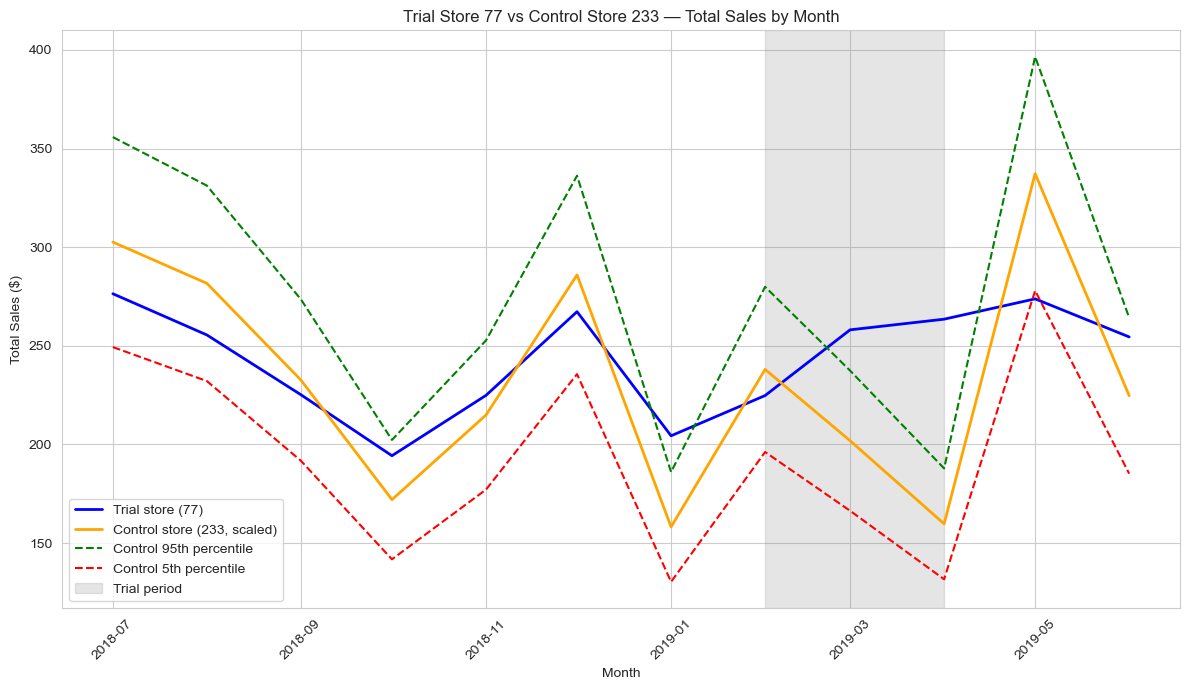

In [19]:
plt.figure(figsize=(12, 7))

# Prepare data: trial store, control store (scaled), and confidence bands
plot_data = pd.merge(control_data_77[['YEARMONTH', 'CONTROL_SALES_SCALED']], trial_data_77, on='YEARMONTH')
plot_data['TransactionMonth'] = pd.to_datetime(plot_data['YEARMONTH'].astype(str), format='%Y%m')

plot_data['CONTROL_95'] = plot_data['CONTROL_SALES_SCALED'] * (1 + std_dev_77 * 2)
plot_data['CONTROL_5'] = plot_data['CONTROL_SALES_SCALED'] * (1 - std_dev_77 * 2)

plt.plot(plot_data['TransactionMonth'], plot_data['TRIAL_SALES'], label='Trial store (77)', color='blue', linewidth=2)
plt.plot(plot_data['TransactionMonth'], plot_data['CONTROL_SALES_SCALED'], label='Control store (233, scaled)', color='orange', linewidth=2)
plt.plot(plot_data['TransactionMonth'], plot_data['CONTROL_95'], label='Control 95th percentile', color='green', linestyle='--')
plt.plot(plot_data['TransactionMonth'], plot_data['CONTROL_5'], label='Control 5th percentile', color='red', linestyle='--')

# Shade the trial period
trial_period = plot_data[(plot_data['YEARMONTH'] >= 201902) & (plot_data['YEARMONTH'] <= 201904)]
plt.axvspan(trial_period['TransactionMonth'].min(), trial_period['TransactionMonth'].max(), color='gray', alpha=0.2, label='Trial period')

plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.title('Trial Store 77 vs Control Store 233 — Total Sales by Month')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Same significance-band visualisation as sales, but for **customer counts**, wrapped as a reusable function.

**Note:** the last two lines compute `std_dev_cust_77` as the raw standard deviation of store 77's own customer counts (`.std()` on `N_CUSTOMERS` directly), rather than the standard deviation of the pre-trial *percentage difference* between store 77 and its scaled control — which is how `std_dev_77` was computed for sales above, and what the ±2σ band is meant to represent. Worth checking whether this band looks right, or recomputing it the same way as the sales version (see how `plot_customer_trial_assessment_86`/`_88` do it correctly further below, by computing `PERCENTAGE_DIFF` internally).

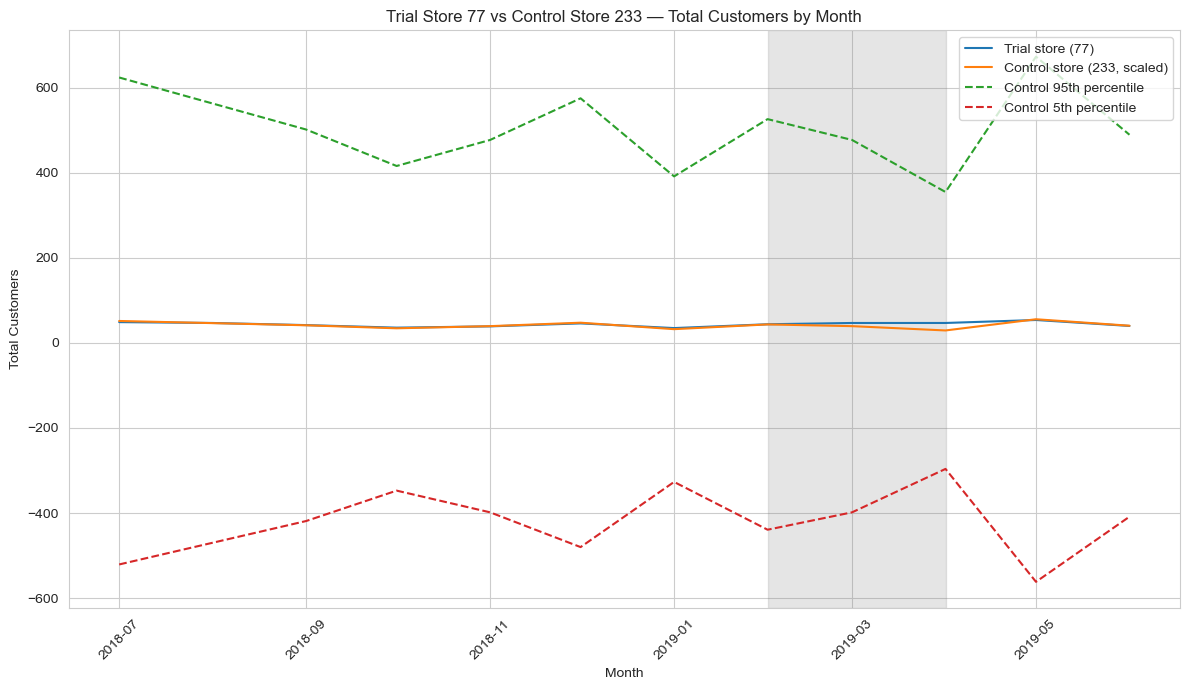

In [20]:
def plot_customer_trial_assessment(trial_store, control_store, std_dev, title_suffix):
    scaling_factor = (
        pretrial_data[pretrial_data['STORE_NBR'] == trial_store]['N_CUSTOMERS'].sum() /
        pretrial_data[pretrial_data['STORE_NBR'] == control_store]['N_CUSTOMERS'].sum()
    )
    control_data = monthly_data[monthly_data['STORE_NBR'] == control_store].copy()
    control_data['CONTROL_SCALED'] = control_data['N_CUSTOMERS'] * scaling_factor

    trial_data = monthly_data[monthly_data['STORE_NBR'] == trial_store][['YEARMONTH', 'N_CUSTOMERS']]
    plot_data = pd.merge(control_data[['YEARMONTH', 'CONTROL_SCALED']], trial_data, on='YEARMONTH')
    plot_data['TransactionMonth'] = pd.to_datetime(plot_data['YEARMONTH'].astype(str), format='%Y%m')
    plot_data['CONTROL_95'] = plot_data['CONTROL_SCALED'] * (1 + std_dev * 2)
    plot_data['CONTROL_5'] = plot_data['CONTROL_SCALED'] * (1 - std_dev * 2)

    plt.figure(figsize=(12, 7))
    plt.plot(plot_data['TransactionMonth'], plot_data['N_CUSTOMERS'], label=f'Trial store ({trial_store})')
    plt.plot(plot_data['TransactionMonth'], plot_data['CONTROL_SCALED'], label=f'Control store ({control_store}, scaled)')
    plt.plot(plot_data['TransactionMonth'], plot_data['CONTROL_95'], '--', label='Control 95th percentile')
    plt.plot(plot_data['TransactionMonth'], plot_data['CONTROL_5'], '--', label='Control 5th percentile')

    trial_period = plot_data[(plot_data['YEARMONTH'] >= 201902) & (plot_data['YEARMONTH'] <= 201904)]
    plt.axvspan(trial_period['TransactionMonth'].min(), trial_period['TransactionMonth'].max(), alpha=0.2, color='gray')

    plt.xlabel('Month')
    plt.ylabel('Total Customers')
    plt.title(f'Trial Store {trial_store} vs Control Store {control_store} — {title_suffix}')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Use the std_dev values you already computed for N_CUSTOMERS in run_significance_test
std_dev_cust_77 = pretrial_data[pretrial_data['STORE_NBR'] == 77]['N_CUSTOMERS'].std()  # or reuse from customers_77 calc
plot_customer_trial_assessment(77, 233, std_dev_cust_77, 'Total Customers by Month')

Scale store 155 (control for trial store 86) to its pre-trial baseline, compute `PERCENTAGE_DIFF`, and run the same t-test as store 77 — all inline rather than via the generic function, since `run_significance_test` hasn't been written yet at this point in the notebook.

In [21]:
control_store_86_num = 155

# Scaling factor
scaling_factor_86 = (
    pretrial_data[pretrial_data['STORE_NBR'] == 86]['TOT_SALES'].sum() /
    pretrial_data[pretrial_data['STORE_NBR'] == 155]['TOT_SALES'].sum()
)
print("Scaling factor for store 155 (control for 86):", scaling_factor_86)

# Apply scaling
control_data_86 = monthly_data[monthly_data['STORE_NBR'] == 155].copy()
control_data_86['CONTROL_SALES_SCALED'] = control_data_86['TOT_SALES'] * scaling_factor_86

# Percentage difference
trial_data_86 = monthly_data[monthly_data['STORE_NBR'] == 86][['YEARMONTH', 'TOT_SALES']]
percentage_diff_86 = pd.merge(
    control_data_86[['YEARMONTH', 'CONTROL_SALES_SCALED']],
    trial_data_86,
    on='YEARMONTH'
)
percentage_diff_86['TRIAL_SALES'] = percentage_diff_86['TOT_SALES']
percentage_diff_86['PERCENTAGE_DIFF'] = abs(percentage_diff_86['TRIAL_SALES'] - percentage_diff_86['CONTROL_SALES_SCALED']) / percentage_diff_86['CONTROL_SALES_SCALED']

# T-test
std_dev_86 = percentage_diff_86[percentage_diff_86['YEARMONTH'] < 201902]['PERCENTAGE_DIFF'].std()
degrees_freedom_86 = 6
critical_t_86 = stats.t.ppf(0.95, degrees_freedom_86)
percentage_diff_86['T_VALUE'] = percentage_diff_86['PERCENTAGE_DIFF'] / std_dev_86

print("Std dev (pre-trial):", std_dev_86)
print("Critical t-value:", critical_t_86)
percentage_diff_86[['YEARMONTH', 'PERCENTAGE_DIFF', 'T_VALUE']]

Scaling factor for store 155 (control for 86): 0.9644090886975137
Std dev (pre-trial): 0.026205894199086366
Critical t-value: 1.9431802803927816


,YEARMONTH,PERCENTAGE_DIFF,T_VALUE
0,201807,0.022309,0.851292
1,201808,0.011536,0.440208
2,201809,0.079033,3.015860
3,201810,0.019978,0.762348
4,201811,0.035471,1.353558
5,201812,0.051840,1.978190
6,201901,0.002921,0.111471
7,201902,0.062798,2.396314
8,201903,0.284142,10.842690
9,201904,0.041433,1.581073


Same scaling + percentage-difference + t-test pipeline for trial store 88 against control store 237.

In [22]:
control_store_88_num = 237

scaling_factor_88 = (
    pretrial_data[pretrial_data['STORE_NBR'] == 88]['TOT_SALES'].sum() /
    pretrial_data[pretrial_data['STORE_NBR'] == 237]['TOT_SALES'].sum()
)
print("Scaling factor for store 237 (control for 88):", scaling_factor_88)

control_data_88 = monthly_data[monthly_data['STORE_NBR'] == 237].copy()
control_data_88['CONTROL_SALES_SCALED'] = control_data_88['TOT_SALES'] * scaling_factor_88

trial_data_88 = monthly_data[monthly_data['STORE_NBR'] == 88][['YEARMONTH', 'TOT_SALES']]
percentage_diff_88 = pd.merge(
    control_data_88[['YEARMONTH', 'CONTROL_SALES_SCALED']],
    trial_data_88,
    on='YEARMONTH'
)
percentage_diff_88['TRIAL_SALES'] = percentage_diff_88['TOT_SALES']
percentage_diff_88['PERCENTAGE_DIFF'] = abs(percentage_diff_88['TRIAL_SALES'] - percentage_diff_88['CONTROL_SALES_SCALED']) / percentage_diff_88['CONTROL_SALES_SCALED']

std_dev_88 = percentage_diff_88[percentage_diff_88['YEARMONTH'] < 201902]['PERCENTAGE_DIFF'].std()
degrees_freedom_88 = 6
critical_t_88 = stats.t.ppf(0.95, degrees_freedom_88)
percentage_diff_88['T_VALUE'] = percentage_diff_88['PERCENTAGE_DIFF'] / std_dev_88

print("Std dev (pre-trial):", std_dev_88)
print("Critical t-value:", critical_t_88)
percentage_diff_88[['YEARMONTH', 'PERCENTAGE_DIFF', 'T_VALUE']]

Scaling factor for store 237 (control for 88): 0.9907684714697534
Std dev (pre-trial): 0.049078157781877525
Critical t-value: 1.9431802803927816


,YEARMONTH,PERCENTAGE_DIFF,T_VALUE
0,201807,0.113646,2.315607
1,201808,0.051536,1.050085
2,201809,0.098888,2.014901
3,201810,0.003465,0.070593
4,201811,0.005790,0.117966
5,201812,0.008180,0.166680
6,201901,0.097544,1.987517
7,201902,0.029765,0.606487
8,201903,0.257361,5.243910
9,201904,0.152281,3.102824


Plot trial store 86 vs. its scaled control (155) with the ±2σ band, same style as store 77's sales chart.

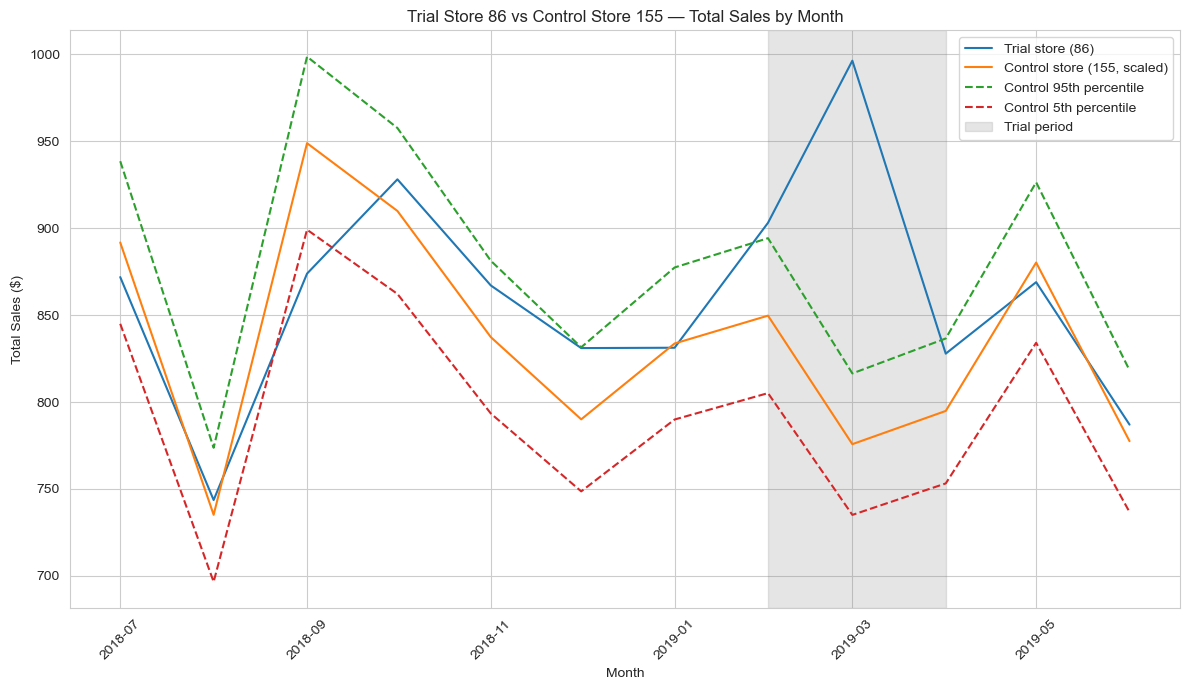

In [23]:
plt.figure(figsize=(12, 7))

plot_data_86 = pd.merge(control_data_86[['YEARMONTH', 'CONTROL_SALES_SCALED']], trial_data_86, on='YEARMONTH')
plot_data_86['TRIAL_SALES'] = plot_data_86['TOT_SALES']
plot_data_86['TransactionMonth'] = pd.to_datetime(plot_data_86['YEARMONTH'].astype(str), format='%Y%m')

plot_data_86['CONTROL_95'] = plot_data_86['CONTROL_SALES_SCALED'] * (1 + std_dev_86 * 2)
plot_data_86['CONTROL_5'] = plot_data_86['CONTROL_SALES_SCALED'] * (1 - std_dev_86 * 2)

plt.plot(plot_data_86['TransactionMonth'], plot_data_86['TRIAL_SALES'], label='Trial store (86)')
plt.plot(plot_data_86['TransactionMonth'], plot_data_86['CONTROL_SALES_SCALED'], label='Control store (155, scaled)')
plt.plot(plot_data_86['TransactionMonth'], plot_data_86['CONTROL_95'], '--', label='Control 95th percentile')
plt.plot(plot_data_86['TransactionMonth'], plot_data_86['CONTROL_5'], '--', label='Control 5th percentile')

trial_period_86 = plot_data_86[(plot_data_86['YEARMONTH'] >= 201902) & (plot_data_86['YEARMONTH'] <= 201904)]
plt.axvspan(trial_period_86['TransactionMonth'].min(), trial_period_86['TransactionMonth'].max(), color='grey', alpha=0.2, label='Trial period')

plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.title('Trial Store 86 vs Control Store 155 — Total Sales by Month')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Customer-count significance chart for store 86. Unlike the store-77 version above, this correctly recomputes `PERCENTAGE_DIFF` and `std_dev` internally from the customer-count scaling, so its ±2σ band is on the right footing.

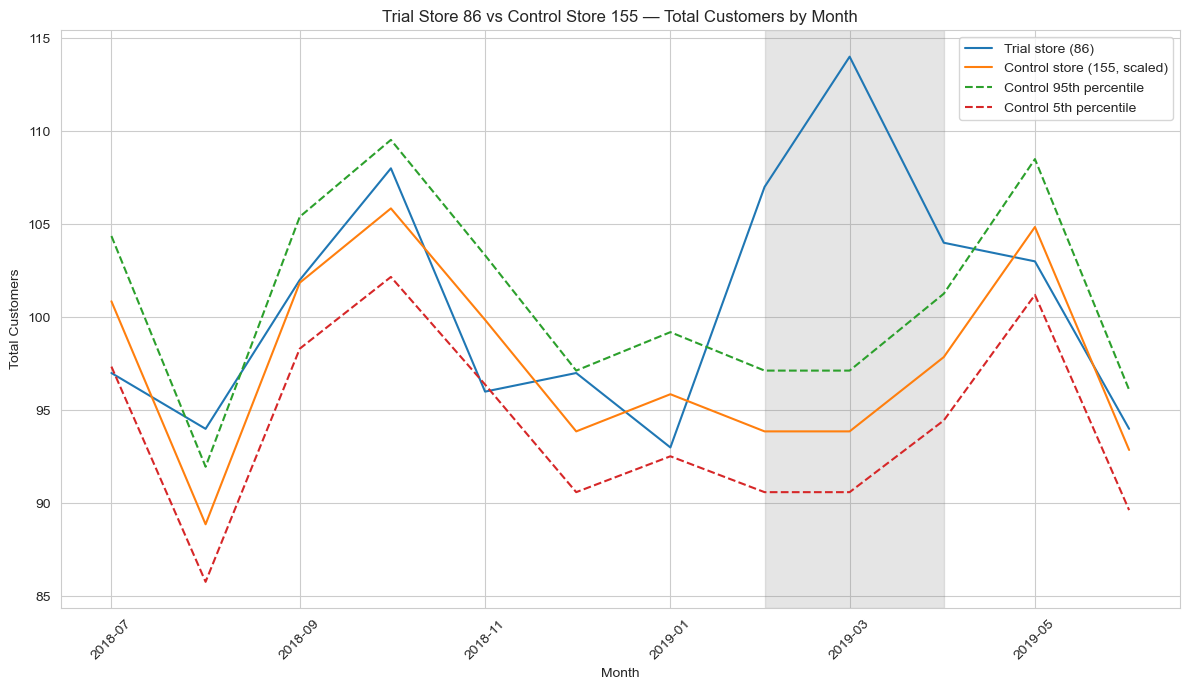

In [24]:
def plot_customer_trial_assessment_86(trial_store, control_store):
    scaling_factor = (
        pretrial_data[pretrial_data['STORE_NBR'] == trial_store]['N_CUSTOMERS'].sum() /
        pretrial_data[pretrial_data['STORE_NBR'] == control_store]['N_CUSTOMERS'].sum()
    )

    control_data = monthly_data[monthly_data['STORE_NBR'] == control_store].copy()
    control_data['CONTROL_SCALED'] = control_data['N_CUSTOMERS'] * scaling_factor

    trial_data = monthly_data[monthly_data['STORE_NBR'] == trial_store][['YEARMONTH', 'N_CUSTOMERS']]

    plot_data = pd.merge(control_data[['YEARMONTH', 'CONTROL_SCALED']], trial_data, on='YEARMONTH')
    plot_data['TransactionMonth'] = pd.to_datetime(plot_data['YEARMONTH'].astype(str), format='%Y%m')

    plot_data['PERCENTAGE_DIFF'] = abs(plot_data['N_CUSTOMERS'] - plot_data['CONTROL_SCALED']) / plot_data['CONTROL_SCALED']
    std_dev = plot_data[plot_data['YEARMONTH'] < 201902]['PERCENTAGE_DIFF'].std()

    plot_data['CONTROL_95'] = plot_data['CONTROL_SCALED'] * (1 + std_dev * 2)
    plot_data['CONTROL_5'] = plot_data['CONTROL_SCALED'] * (1 - std_dev * 2)

    plt.figure(figsize=(12, 7))
    plt.plot(plot_data['TransactionMonth'], plot_data['N_CUSTOMERS'], label=f'Trial store ({trial_store})')
    plt.plot(plot_data['TransactionMonth'], plot_data['CONTROL_SCALED'], label=f'Control store ({control_store}, scaled)')
    plt.plot(plot_data['TransactionMonth'], plot_data['CONTROL_95'], '--', label='Control 95th percentile')
    plt.plot(plot_data['TransactionMonth'], plot_data['CONTROL_5'], '--', label='Control 5th percentile')

    trial_period = plot_data[(plot_data['YEARMONTH'] >= 201902) & (plot_data['YEARMONTH'] <= 201904)]
    plt.axvspan(trial_period['TransactionMonth'].min(), trial_period['TransactionMonth'].max(), alpha=0.2, color='gray')

    plt.xlabel('Month')
    plt.ylabel('Total Customers')
    plt.title(f'Trial Store {trial_store} vs Control Store {control_store} — Total Customers by Month')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_customer_trial_assessment_86(86, 155)

Sales significance chart for trial store 88 vs. control 237.

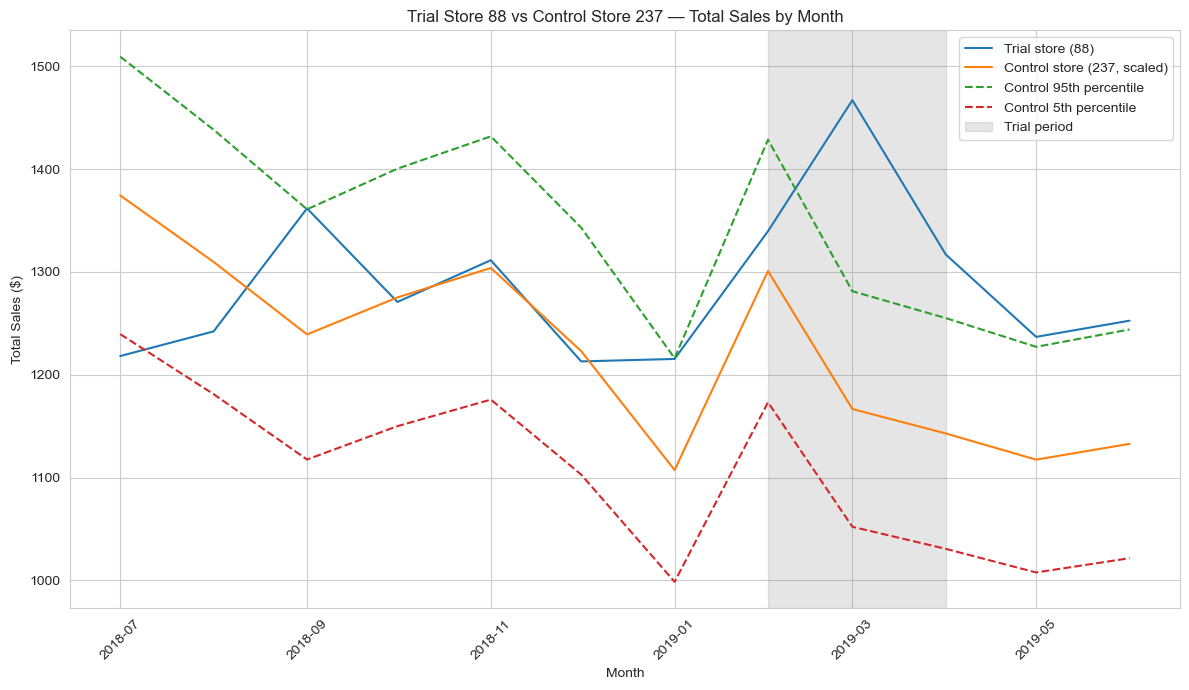

In [25]:
plt.figure(figsize=(12, 7))

plot_data_88 = pd.merge(control_data_88[['YEARMONTH', 'CONTROL_SALES_SCALED']], trial_data_88, on='YEARMONTH')
plot_data_88['TRIAL_SALES'] = plot_data_88['TOT_SALES']
plot_data_88['TransactionMonth'] = pd.to_datetime(plot_data_88['YEARMONTH'].astype(str), format='%Y%m')

plot_data_88['CONTROL_95'] = plot_data_88['CONTROL_SALES_SCALED'] * (1 + std_dev_88 * 2)
plot_data_88['CONTROL_5'] = plot_data_88['CONTROL_SALES_SCALED'] * (1 - std_dev_88 * 2)

plt.plot(plot_data_88['TransactionMonth'], plot_data_88['TRIAL_SALES'], label='Trial store (88)')
plt.plot(plot_data_88['TransactionMonth'], plot_data_88['CONTROL_SALES_SCALED'], label='Control store (237, scaled)')
plt.plot(plot_data_88['TransactionMonth'], plot_data_88['CONTROL_95'], '--', label='Control 95th percentile')
plt.plot(plot_data_88['TransactionMonth'], plot_data_88['CONTROL_5'], '--', label='Control 5th percentile')

trial_period_88 = plot_data_88[(plot_data_88['YEARMONTH'] >= 201902) & (plot_data_88['YEARMONTH'] <= 201904)]
plt.axvspan(trial_period_88['TransactionMonth'].min(), trial_period_88['TransactionMonth'].max(), color='grey', alpha=0.2, label='Trial period')

plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.title('Trial Store 88 vs Control Store 237 — Total Sales by Month')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Customer-count significance chart for trial store 88 vs. control 237, computed the same correct way as store 86's version above.

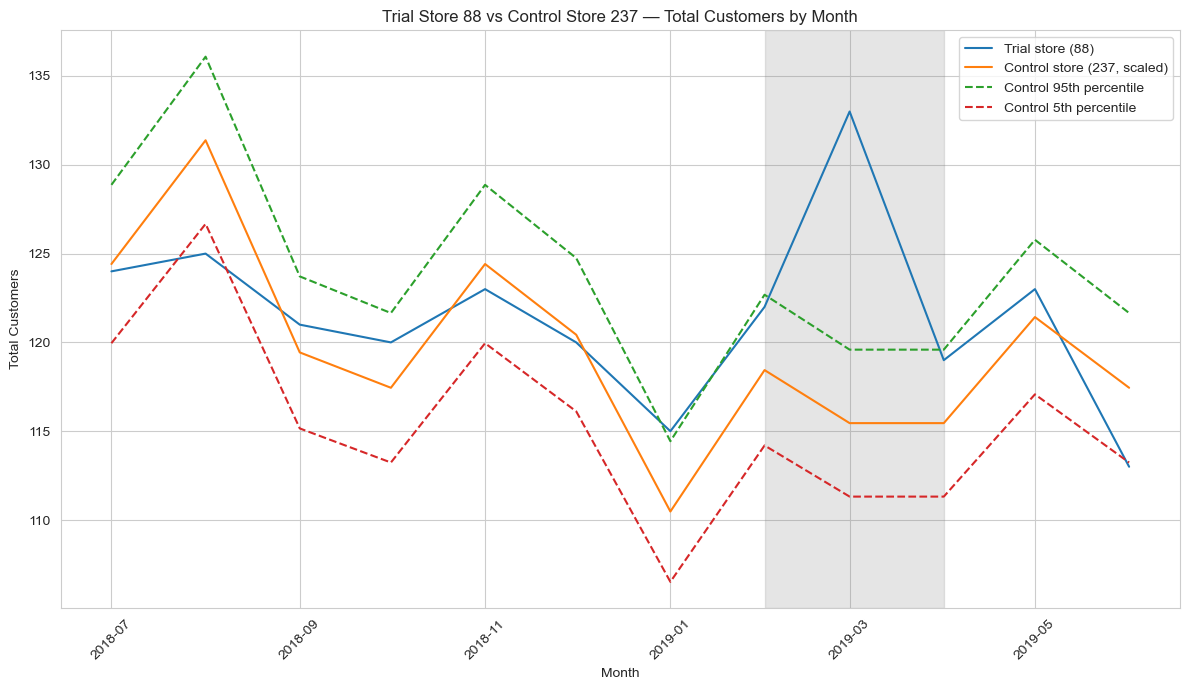

In [26]:
def plot_customer_trial_assessment_88(trial_store, control_store):
    scaling_factor = (
        pretrial_data[pretrial_data['STORE_NBR'] == trial_store]['N_CUSTOMERS'].sum() /
        pretrial_data[pretrial_data['STORE_NBR'] == control_store]['N_CUSTOMERS'].sum()
    )

    control_data = monthly_data[monthly_data['STORE_NBR'] == control_store].copy()
    control_data['CONTROL_SCALED'] = control_data['N_CUSTOMERS'] * scaling_factor

    trial_data = monthly_data[monthly_data['STORE_NBR'] == trial_store][['YEARMONTH', 'N_CUSTOMERS']]

    plot_data = pd.merge(control_data[['YEARMONTH', 'CONTROL_SCALED']], trial_data, on='YEARMONTH')
    plot_data['TransactionMonth'] = pd.to_datetime(plot_data['YEARMONTH'].astype(str), format='%Y%m')

    plot_data['PERCENTAGE_DIFF'] = abs(plot_data['N_CUSTOMERS'] - plot_data['CONTROL_SCALED']) / plot_data['CONTROL_SCALED']
    std_dev = plot_data[plot_data['YEARMONTH'] < 201902]['PERCENTAGE_DIFF'].std()

    plot_data['CONTROL_95'] = plot_data['CONTROL_SCALED'] * (1 + std_dev * 2)
    plot_data['CONTROL_5'] = plot_data['CONTROL_SCALED'] * (1 - std_dev * 2)

    plt.figure(figsize=(12, 7))
    plt.plot(plot_data['TransactionMonth'], plot_data['N_CUSTOMERS'], label=f'Trial store ({trial_store})')
    plt.plot(plot_data['TransactionMonth'], plot_data['CONTROL_SCALED'], label=f'Control store ({control_store}, scaled)')
    plt.plot(plot_data['TransactionMonth'], plot_data['CONTROL_95'], '--', label='Control 95th percentile')
    plt.plot(plot_data['TransactionMonth'], plot_data['CONTROL_5'], '--', label='Control 5th percentile')

    trial_period = plot_data[(plot_data['YEARMONTH'] >= 201902) & (plot_data['YEARMONTH'] <= 201904)]
    plt.axvspan(trial_period['TransactionMonth'].min(), trial_period['TransactionMonth'].max(), alpha=0.2, color='gray')

    plt.xlabel('Month')
    plt.ylabel('Total Customers')
    plt.title(f'Trial Store {trial_store} vs Control Store {control_store} — Total Customers by Month')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_customer_trial_assessment_88(88, 237)

## Generalise the assessment into one reusable function
Everything done manually above for sales and customers — scaling, percentage difference, pre-trial standard deviation, t-values — is wrapped here as `run_significance_test(store_num, control_num, metric_col, ...)`, so it can be applied to *any* metric column for any trial-control pair without copy-pasting the pipeline again. This is what makes it cheap to check `TXN_PER_CUSTOMER` next, to see whether purchase frequency — rather than customer count — is driving any sales change.

In [27]:
def run_significance_test(store_num, control_num, metric_col, pretrial_data, monthly_data):
    """
    Runs the scaling + percentage-diff + t-test pipeline for any metric
    (e.g. 'N_CUSTOMERS', 'TXN_PER_CUSTOMER') between a trial store and its control.
    """
    # Scaling factor based on pre-trial period
    scaling_factor = (
        pretrial_data[pretrial_data['STORE_NBR'] == store_num][metric_col].sum() /
        pretrial_data[pretrial_data['STORE_NBR'] == control_num][metric_col].sum()
    )

    # Apply scaling across all months
    control_data = monthly_data[monthly_data['STORE_NBR'] == control_num].copy()
    control_data['CONTROL_SCALED'] = control_data[metric_col] * scaling_factor

    # Trial store actuals
    trial_data = monthly_data[monthly_data['STORE_NBR'] == store_num][['YEARMONTH', metric_col]]
    trial_data = trial_data.rename(columns={metric_col: 'TRIAL_VALUE'})

    # Percentage difference
    result = pd.merge(control_data[['YEARMONTH', 'CONTROL_SCALED']], trial_data, on='YEARMONTH')
    result['PERCENTAGE_DIFF'] = abs(result['TRIAL_VALUE'] - result['CONTROL_SCALED']) / result['CONTROL_SCALED']

    # T-test using pre-trial std dev
    std_dev = result[result['YEARMONTH'] < 201902]['PERCENTAGE_DIFF'].std()
    degrees_freedom = 6
    critical_t = stats.t.ppf(0.95, degrees_freedom)
    result['T_VALUE'] = result['PERCENTAGE_DIFF'] / std_dev

    print(f"Store {store_num} vs Control {control_num} — {metric_col}")
    print("Std dev (pre-trial):", std_dev)
    print("Critical t-value:", critical_t)

    return result[['YEARMONTH', 'PERCENTAGE_DIFF', 'T_VALUE']]

Run the generalised significance test for store 77 on both `N_CUSTOMERS` and `TXN_PER_CUSTOMER`, to identify which of the two is driving the sales change found earlier.

In [28]:
# Store 77 (control 233)
customers_77 = run_significance_test(77, 233, 'N_CUSTOMERS', pretrial_data, monthly_data)
print(customers_77)

txn_per_cust_77 = run_significance_test(77, 233, 'TXN_PER_CUSTOMER', pretrial_data, monthly_data)
print(txn_per_cust_77)

Store 77 vs Control 233 — N_CUSTOMERS
Std dev (pre-trial): 0.02616946382885311
Critical t-value: 1.9431802803927816
    YEARMONTH  PERCENTAGE_DIFF    T_VALUE
0      201807         0.052288   1.998038
1      201808         0.007838   0.299506
2      201809         0.010453   0.399434
3      201810         0.044418   1.697313
4      201811         0.013605   0.519898
5      201812         0.034593   1.321867
6      201901         0.078869   3.013782
7      201902         0.009334   0.356674
8      201903         0.188732   7.211913
9      201904         0.598639  22.875496
10     201905         0.031540   1.205217
11     201906         0.013605   0.519898
Store 77 vs Control 233 — TXN_PER_CUSTOMER
Std dev (pre-trial): 0.0299157416067038
Critical t-value: 1.9431802803927816
    YEARMONTH  PERCENTAGE_DIFF   T_VALUE
0      201807         0.001792  0.059900
1      201808         0.043632  1.458511
2      201809         0.046108  1.541246
3      201810         0.004301  0.143785
4      201811

Same driver analysis for store 86.

In [29]:
# Store 86 (control 155)
customers_86 = run_significance_test(86, 155, 'N_CUSTOMERS', pretrial_data, monthly_data)
print(customers_86)

txn_per_cust_86 = run_significance_test(86, 155, 'TXN_PER_CUSTOMER', pretrial_data, monthly_data)
print(txn_per_cust_86.to_string())

Store 86 vs Control 155 — N_CUSTOMERS
Std dev (pre-trial): 0.017397486358535403
Critical t-value: 1.9431802803927816
    YEARMONTH  PERCENTAGE_DIFF    T_VALUE
0      201807         0.038206   2.196065
1      201808         0.057717   3.317557
2      201809         0.001456   0.083667
3      201810         0.020351   1.169766
4      201811         0.038603   2.218862
5      201812         0.033417   1.920792
6      201901         0.029840   1.715184
7      201902         0.139955   8.044540
8      201903         0.214531  12.331164
9      201904         0.062769   3.607947
10     201905         0.017620   1.012775
11     201906         0.012224   0.702627
Store 86 vs Control 155 — TXN_PER_CUSTOMER
Std dev (pre-trial): 0.042357126910592
Critical t-value: 1.9431802803927816
    YEARMONTH  PERCENTAGE_DIFF   T_VALUE
0      201807         0.078232  1.846973
1      201808         0.094530  2.231735
2      201809         0.096665  2.282146
3      201810         0.023204  0.547828
4      201811

Inspect the transactions-per-customer result for store 86 specifically around the trial's start (January-February 2019), to see the transition into the trial period at a glance.

In [30]:
print(txn_per_cust_86[txn_per_cust_86['YEARMONTH'].isin([201901, 201902])])

   YEARMONTH  PERCENTAGE_DIFF   T_VALUE
6     201901         0.094518  2.231446
7     201902         0.003014  0.071152


Same driver analysis for store 88.

In [31]:
# Store 88 (control 237)
customers_88 = run_significance_test(88, 237, 'N_CUSTOMERS', pretrial_data, monthly_data)
print(customers_88)

txn_per_cust_88 = run_significance_test(88, 237, 'TXN_PER_CUSTOMER', pretrial_data, monthly_data)
print(txn_per_cust_88)

Store 88 vs Control 237 — N_CUSTOMERS
Std dev (pre-trial): 0.017915383598410627
Critical t-value: 1.9431802803927816
    YEARMONTH  PERCENTAGE_DIFF   T_VALUE
0      201807         0.003321  0.185358
1      201808         0.048563  2.710713
2      201809         0.013090  0.730636
3      201810         0.021746  1.213822
4      201811         0.011358  0.634008
5      201812         0.003586  0.200189
6      201901         0.040923  2.284238
7      201902         0.030046  1.677105
8      201903         0.151960  8.482095
9      201904         0.030701  1.713669
10     201905         0.012952  0.722975
11     201906         0.037856  2.113032
Store 88 vs Control 237 — TXN_PER_CUSTOMER
Std dev (pre-trial): 0.02272555153684973
Critical t-value: 1.9431802803927816
    YEARMONTH  PERCENTAGE_DIFF   T_VALUE
0      201807         0.071122  3.129616
1      201808         0.011748  0.516968
2      201809         0.052730  2.320276
3      201810         0.023367  1.028217
4      201811         0.

Inspect the transactions-per-customer result for store 88 around the trial's start (January-February 2019).

In [32]:
print(txn_per_cust_88[txn_per_cust_88['YEARMONTH'].isin([201901, 201902])])

   YEARMONTH  PERCENTAGE_DIFF   T_VALUE
6     201901         0.045673  2.009754
7     201902         0.013155  0.578857


## Summary of Findings

### Methodology
For each trial store (77, 86, 88), a control store was selected from stores with full 12-month
pre-trial data, using a combined score of Pearson correlation (trend similarity) and standardised
magnitude distance (scale similarity) on total sales and customer counts. The best-matching control
stores were: Store 233 (for 77), Store 155 (for 86), and Store 237 (for 88).

Control store sales were scaled to match each trial store's pre-trial baseline, then compared
against actual trial store sales for Feb–Apr 2019 using a t-test (95% confidence, 6 degrees of
freedom from 7 pre-trial months).

### Results
- **Trial Store 77 vs Control 233:** Significant sales uplift in March (t=3.16) and April (t=7.38),
  not significant in February (t=0.63). The uplift was driven almost entirely by an increase in
  customer numbers (t=7.21 in March, t=22.88 in April), with only a mild effect on transactions
  per customer.
- **Trial Store 86 vs Control 155:** Significant sales uplift in February (t=2.40) and March
  (t=10.84), not significant in April (t=1.58). The uplift was entirely driven by more customers
  (t=8.04, t=12.33); transactions per customer showed no significant change in either month.
- **Trial Store 88 vs Control 237:** Significant sales uplift in March (t=5.24) and April
  (t=3.10), not significant in February (t=0.61). March's uplift came from both more customers
  (t=8.48) and more transactions per customer (t=5.13). By April, the driver shifted — customer
  count was no longer significant (t=1.71), while transactions per customer remained strongly
  significant (t=5.40).

### Conclusion
All three trial stores showed a statistically significant sales uplift during the trial period,
providing strong evidence the trial had a genuine positive effect. Across stores, the primary
driver was an increase in the number of customers shopping at the store — except for Store 88 in
April, where the effect shifted toward existing customers purchasing more frequently. This
suggests the trial may have had a lasting effect on customer loyalty specifically at Store 88,
worth investigating further.